# 02 · Explore referral operations

**Question:** How do simulated acuity, documentation completeness, and capacity interact? This notebook explores the training partition; final test results belong in notebook 05.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
get_ipython().run_line_magic('matplotlib', 'inline')

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
DATA = ROOT / 'data/synthetic/transfer_requests.csv'
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False, 'axes.spines.right': False})


In [2]:
all_data = pd.read_csv(DATA)
df = all_data[all_data.split.eq('train')].copy()
print(f'Training referrals: {len(df)}')
display(df[['patient_age','systolic_bp','heart_rate','spo2']].describe())

Training referrals: 625


,patient_age,systolic_bp,heart_rate,spo2
count,625.000000,625.000000,625.000000,625.000000
mean,56.214400,127.803200,93.550400,95.582400
std,22.531576,20.153529,19.785657,3.150602
min,18.000000,78.000000,60.000000,88.000000
25%,37.000000,115.000000,76.000000,94.000000
50%,55.000000,127.000000,95.000000,96.000000
75%,76.000000,145.000000,107.000000,98.000000
max,95.000000,159.000000,135.000000,100.000000


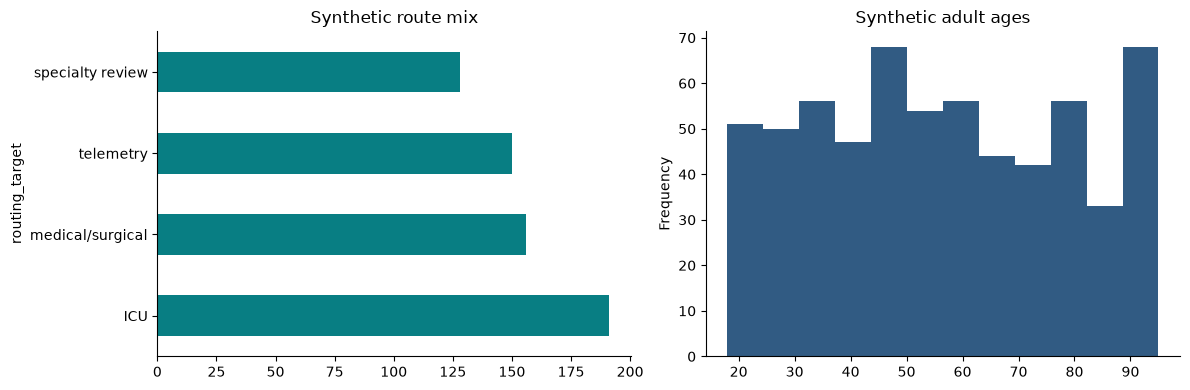

In [3]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
df.routing_target.value_counts().plot.barh(ax=axes[0],color='#087E83',title='Synthetic route mix')
df.patient_age.plot.hist(ax=axes[1],bins=12,color='#315B83',title='Synthetic adult ages')
fig.tight_layout()
plt.show()

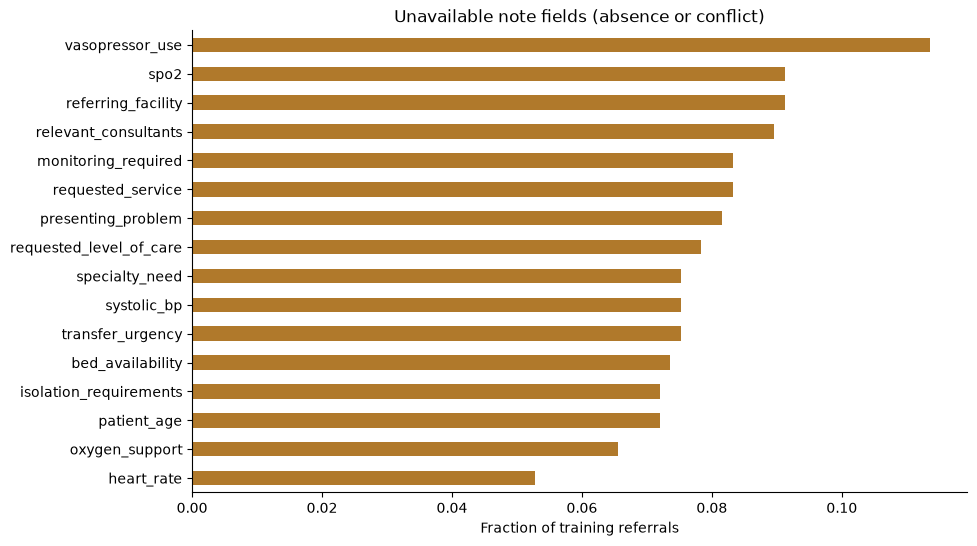

In [4]:
from transfer_assistant.schema import FIELDS
visible = pd.DataFrame([json.loads(s) for s in df.visible_annotations])
missing = visible.isna().mean().sort_values()
missing.plot.barh(color='#B0792B',title='Unavailable note fields (absence or conflict)',figsize=(10,6))
plt.xlabel('Fraction of training referrals')
plt.show()

In [5]:
df['unavailable_count'] = [sum(v is None for v in json.loads(s).values()) for s in df.visible_annotations]
display(df.groupby('referring_facility').agg(n=('request_id','size'),mean_unavailable=('unavailable_count','mean')))
display(pd.crosstab(df.bed_availability,df.transfer_outcome,normalize='index').round(3))

,n,mean_unavailable
referring_facility,,
Synthetic Lakeside Center,108,1.129630
Synthetic North Hospital,117,1.205128
Synthetic Prairie Hospital,121,0.991736
Synthetic Valley ED,142,0.943662
Synthetic West Community,137,2.036496


transfer_outcome,accepted,capacity delay,pending clarification,redirected
bed_availability,,,,
available,0.582,0.132,0.209,0.077
limited,0.684,0.085,0.193,0.038
unavailable,0.243,0.521,0.171,0.064


## Operational interpretation
The generator makes documentation completeness depend on fictional referral source and outcomes depend on capacity. These relationships are designed, not discovered healthcare facts. The prototype keeps capacity outside acuity prediction to avoid normalizing lower-acuity placement when a bed is unavailable. Facility-specific missingness can still create unequal abstention burden.

In [6]:
display(df.groupby('routing_target')[['systolic_bp','heart_rate','spo2']].mean().round(1))

,systolic_bp,heart_rate,spo2
routing_target,,,
ICU,114.6,114.2,92.2
medical/surgical,133.2,84.1,97.2
specialty review,134.2,85.0,97.0
telemetry,133.5,84.4,97.0


## Modeling risk
Strong scenario–vital associations make this synthetic problem easier than clinical practice. The model may infer missing support from proxies. Exclude outcome, scenario ID, requested bed, and hidden truth; analyze incomplete-referral failures separately.